In [ ]:
!nvidia-smi

Fri Apr 17 16:34:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q gdown
import gdown
import zipfile
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset
import os
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch.utils.data import Subset
import torch.optim as optim
import copy
from IPython.display import display
import time
import subprocess
import psutil
import torch.optim.lr_scheduler as lr_sched
import datetime

In [3]:
# PARAMETERS

SEED = 42
TRAIN_VAL_SPLIT = 0.8
TRAINING_DATA_PERCENTAGE = 0.2
SMALLER_DATASET = False

In [4]:
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

random.seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
torch.use_deterministic_algorithms(False)

set_seed(SEED)

# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # wymagane przez niektóre operacje CUDA (determinizm)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.files = sorted([f for f in os.listdir(root_dir) if f != ".gitkeep"])
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_name = self.files[idx]
        img_path = os.path.join(self.root_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_name

In [6]:
train_file_id = "1Qap-JOj0ZW-p-rS84S-fzggZPbqulQyN"
test_file_id = "1KEt3fVERZg7mLLkcwBfxy_QXtqlqa_Sf"
gdown.download(id=train_file_id, output="train.zip", quiet=False)
gdown.download(id=test_file_id, output="test.zip", quiet=False)

with zipfile.ZipFile("train.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

with zipfile.ZipFile("test.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

TRAIN_PATH = "/content/data/train"
TEST_PATH = "/content/data/test"

Downloading...
From (original): https://drive.google.com/uc?id=1Qap-JOj0ZW-p-rS84S-fzggZPbqulQyN
From (redirected): https://drive.google.com/uc?id=1Qap-JOj0ZW-p-rS84S-fzggZPbqulQyN&confirm=t&uuid=2e579eb7-5719-465e-822d-371edff69868
To: /content/train.zip
100%|██████████| 156M/156M [00:01<00:00, 93.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KEt3fVERZg7mLLkcwBfxy_QXtqlqa_Sf
To: /content/test.zip
100%|██████████| 17.5M/17.5M [00:00<00:00, 80.3MB/s]


Example test


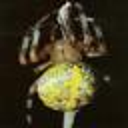

In [7]:
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.ImageFolder(TRAIN_PATH)
testset = TestDataset(TEST_PATH)

map_class_to_idx = trainset.class_to_idx  # map nazwy klasy na index
print('Example test')
display(testset[4][0].resize((128, 128)))
# testset[4][0].resize((128, 128)).show()

first train element: (<PIL.Image.Image image mode=RGB size=64x64 at 0x786D0CF6C740>, 4)


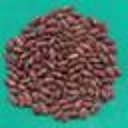

PIL -> Numpy: shape=(64, 64, 3) | dtype=uint8 | min=0 | max=220


In [8]:
sample = trainset[7777]
print("first train element:", sample)
display(sample[0].resize((128, 128)))
# sample[0].resize((128, 128)).show()
np_sample = np.array(sample[0])
print(
    f"PIL -> Numpy: shape={np_sample.shape} | dtype={np_sample.dtype} | min={np_sample.min()} | max={np_sample.max()}"
)

In [9]:
transform_to_tensor = transforms.Compose([transforms.ToTensor()])
full_dataset = torchvision.datasets.ImageFolder(TRAIN_PATH, transform=transform_to_tensor)

train_size = int(TRAIN_VAL_SPLIT * len(full_dataset))
val_size = len(full_dataset) - train_size

trainset, validset = random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)

sample = trainset[4]
print('przed skalowaniem')
print(
    f"PIL -> Tensor: shape={sample[0].shape} | dtype={sample[0].dtype} | min={sample[0].min()} | max={sample[0].max()}",
)


loader = DataLoader(trainset, batch_size=256, shuffle=False)

# global
sum_all = 0.0
sum_sq_all = 0.0
n_all = 0

# per channel
sum_c = 0.0
sum_sq_c = 0.0
n_c = 0

for images, _ in loader:
    b, c, h, w = images.shape

    # -------- GLOBAL --------
    sum_all += images.sum()
    sum_sq_all += (images ** 2).sum()
    n_all += images.numel()

    # -------- CHANNEL --------
    sum_c += images.sum(dim=(0, 2, 3))
    sum_sq_c += (images ** 2).sum(dim=(0, 2, 3))
    n_c += b * h * w


# GLOBAL stats
global_mean = sum_all / n_all
global_std = (sum_sq_all / n_all - global_mean**2).sqrt()

# CHANNEL stats
channel_mean = sum_c / n_c
channel_std = (sum_sq_c / n_c - channel_mean**2).sqrt()

stats = {"global_mean": global_mean, "global_std": global_std, "channel_mean": channel_mean, "channel_std": channel_std}
torch.save(stats, "norm_stats.pt")

print(f"Global: mean={global_mean:.4f} | std={global_std:.4f}")
print(f"Channel: mean={channel_mean} | std={channel_std}")

przed skalowaniem
PIL -> Tensor: shape=torch.Size([3, 64, 64]) | dtype=torch.float32 | min=0.0 | max=1.0
Global: mean=0.4849 | std=0.2884
Channel: mean=tensor([0.5209, 0.4955, 0.4384]) | std=tensor([0.2841, 0.2771, 0.2976])


In [10]:
stats = torch.load("norm_stats.pt")
mean = stats["channel_mean"]
std = stats["channel_std"]

train_transform = transforms.Compose([
    # possible augmentation
    # niezrownowazone klasy bread i carbon
    # transforms.RandomApply(
    #     [
    #         transforms.CenterCrop(int(0.8*64)),
    #         transforms.Resize(64)
    #     ],
    #     p=0.5
    # ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.25),
    # transforms.RandomRotation(degrees=(-15, 15)),
    # transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)), # too strong
    transforms.GaussianBlur(kernel_size=(3), sigma=(0.1, 1)),
    # transforms.RandomInvert(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)]
)

test_transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(mean, std)]
)

base_dataset = torchvision.datasets.ImageFolder(TRAIN_PATH)
train_idx, val_idx = random_split(
    range(len(base_dataset)),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)
trainset = Subset(
    torchvision.datasets.ImageFolder(TRAIN_PATH, transform=train_transform), train_idx
)
if SMALLER_DATASET:
    n = len(trainset)
    k = int(TRAINING_DATA_PERCENTAGE * n)
    new_indices = torch.randperm(n)[:k]
    trainset_small = Subset(trainset, new_indices)
    trainset=trainset_small

validset = Subset(
    torchvision.datasets.ImageFolder(TRAIN_PATH, transform=test_transform), val_idx
)
if SMALLER_DATASET:
    n = len(validset)
    k = int(TRAINING_DATA_PERCENTAGE * n)
    new_indices = torch.randperm(n)[:k]
    validset_small = Subset(validset, new_indices)
    validset = validset_small

testset = TestDataset(TEST_PATH, transform=test_transform)

print('liczby przykladow ')
print('train dataset:', len(trainset))
print('validation dataset:', len(validset))
print('test dataset:', len(testset))

sample = trainset[4]

print('\npo skalowaniu')
print(
    f"PIL -> Tensor: shape={sample[0].shape} | dtype={sample[0].dtype} | min={sample[0].min()} | max={sample[0].max()}"
)


loader = DataLoader(trainset, batch_size=256, shuffle=False)

# global
sum_all = 0.0
sum_sq_all = 0.0
n_all = 0

# per channel
sum_c = 0.0
sum_sq_c = 0.0
n_c = 0

for images, _ in loader:
    b, c, h, w = images.shape

    # -------- GLOBAL --------
    sum_all += images.sum()
    sum_sq_all += (images**2).sum()
    n_all += images.numel()

    # -------- CHANNEL --------
    sum_c += images.sum(dim=(0, 2, 3))
    sum_sq_c += (images**2).sum(dim=(0, 2, 3))
    n_c += b * h * w


# GLOBAL stats
global_mean = sum_all / n_all
global_std = (sum_sq_all / n_all - global_mean**2).sqrt()

# CHANNEL stats
channel_mean = sum_c / n_c
channel_std = (sum_sq_c / n_c - channel_mean**2).sqrt()

print(f"Global: mean={global_mean:.4f} | std={global_std:.4f}")
print(f"Channel: mean={channel_mean} | std={channel_std}")

liczby przykladow 
train dataset: 70408
validation dataset: 17603
test dataset: 10000

po skalowaniu
PIL -> Tensor: shape=torch.Size([3, 64, 64]) | dtype=torch.float32 | min=-1.7922033071517944 | max=1.6177030801773071
Global: mean=0.0000 | std=0.9795
Channel: mean=tensor([ 2.1325e-05,  4.8476e-06, -1.8811e-05]) | std=tensor([0.9791, 0.9780, 0.9814])


In [11]:
idx_to_class = {v: k for k, v in map_class_to_idx.items()}
class_counts = {class_name: 0 for class_name in map_class_to_idx.keys()}

for _, label in trainset:
    class_name = idx_to_class[label]
    class_counts[class_name] += 1

# print('Liczba przykładów w każdej klasie:')
# class_counts

In [12]:
weights = torch.tensor(list(class_counts.values()), dtype=torch.float32).to(device)
weights = 1.0 / weights
weights = weights / weights.sum() * len(weights)
print('Wagi dla każdej klasy:')
weights

Wagi dla każdej klasy:


tensor([0.9358, 0.9489, 0.9358, 0.9332, 0.9391, 0.9430, 0.9371, 0.9294, 0.9281,
        0.9496, 1.5615, 0.9476, 0.9404, 3.3722, 0.9404, 0.9443, 0.9262, 0.9404,
        0.9345, 0.9365, 0.9365, 0.9523, 0.9410, 0.9590, 0.9275, 0.9584, 0.9218,
        0.9307, 0.9256, 0.9275, 0.9358, 0.9516, 0.9365, 0.9450, 0.9436, 0.9137,
        0.9543, 0.9384, 0.9397, 0.9345, 0.9430, 0.9237, 0.9410, 0.9262, 0.9391,
        0.9352, 0.9577, 0.9543, 0.9450, 0.9378])

In [13]:
class Net(nn.Module):
    def __init__(self, act_fn):
        super().__init__()
        self.act_fn = act_fn

        self.block1=nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            act_fn,
            nn.MaxPool2d(2),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            act_fn,
            nn.MaxPool2d(2),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            act_fn,
            nn.MaxPool2d(2),
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            act_fn,
            nn.MaxPool2d(2),
        )

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        # !!!
        self.fc1 = nn.Linear(256, 50)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.avg_pool(x)
        x = torch.flatten(x, start_dim=1)
        # print('after flatten:', x.shape)
        # !!!
        x = self.dropout(x)
        x = self.fc1(x)
        return x

# wiecej epok 120->200 i pelny dataset

In [14]:
# MORE PARAMETERS

LR = 5e-3 # moze zwikeszyc bo krzywe wygladaja jakby duze lr dzialalo by lepiej
LR_ETA_MIN = 5e-4 # moze zwikeszyc bo krzywe wygladaja jakby duze lr dzialalo by lepiej
BATCH_SIZE = 256 #maybe try larger (64-128)
LOSS_FN = nn.CrossEntropyLoss(weight=weights).to(device)
OPTIMIZER = optim.AdamW
TRAIN_EPOCHS = 160 # takes about 36 epochs per hour
# REGULARIZATION = 'L2'
LAMBDA_REG = 5e-4 # moznaby dac nieco wieksze niz 3e-4
ACT_FN = nn.SiLU() # try wider or leakyrelu
SCHEDULER = lr_sched.CosineAnnealingLR
SCHEDULER_T_MAX = TRAIN_EPOCHS

In [15]:
set_seed(SEED)

net = Net(act_fn=ACT_FN).to(device)
optimizer = OPTIMIZER(net.parameters(), lr=LR, weight_decay=LAMBDA_REG)
scheduler = SCHEDULER(
    optimizer,
    T_max=SCHEDULER_T_MAX,  # długość "cyklu"
    eta_min=LR_ETA_MIN         # minimalny learning rate
)

total_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params}")

net

Trainable parameters: 402226


Net(
  (act_fn): SiLU()
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [16]:
def calc_accuracy(predictions: np.ndarray, targets: np.ndarray, n_classes=50):
    assert len(predictions) == len(targets)
    accuracies = []
    for i in range(n_classes):
        accuracies.append((predictions[targets == i] == i).sum() / (targets == i).sum())
    return np.mean(accuracies)

In [17]:
def evaluate_model(model, dataset, loss_module, acc_module=calc_accuracy):
    loader = DataLoader(
        dataset, batch_size=1000, shuffle=False, num_workers=2, pin_memory=True
    )
    model.eval()
    loss = 0
    n_samples = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            preds = model(x)
            y = y.long()
            loss += loss_module(preds, y).item() * x.size(0)  # sum loss over batch
            n_samples += x.size(0)

            preds = torch.argmax(preds, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    loss = loss / n_samples if n_samples > 0 else 0

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    acc = acc_module(all_preds, all_targets)
    return loss, acc

In [18]:
def train_model(
    model,
    train_dataset,
    valid_dataset,
    batch_size,
    num_epochs,
    loss_module,
    optimizer,
    scheduler,
    lr,
    eta_min,
    lambda_reg,
    verbose=0,
    print_loss_n_times=20,
):
    def print_and_log(*args):
        txt = " ".join(str(arg) for arg in args)
        print(txt)
        with open("trainingresults.log", "a") as f:
            f.write(txt + "\n")

    with open("trainingresults.log", "a") as f:
        f.write(
            "\n\n" + "------------------------------------------------------" + "\n"
        )
    timestamp = datetime.datetime.now().strftime("%H:%M:%S %d.%m.%Y")
    print_and_log(f"TIMESTAMP: {timestamp}")
    print_and_log("--- TRAINING FOR PARAMS ---")
    print_and_log(
        f"model architecture:",
        [len(p) for idx, p in enumerate(model.parameters()) if idx % 2 == 0],
    )
    if SMALLER_DATASET:
        print_and_log(f"{TRAINING_DATA_PERCENTAGE=}")
    else:
        print_and_log(f"Full dataset")
    print_and_log(f"{batch_size=}")
    print_and_log(f"{model.act_fn=}")
    print_and_log(f"{num_epochs=}")
    print_and_log(f"{lr=}")
    print_and_log(f"{eta_min=}")
    print_and_log(f"{lambda_reg=}")
    print_and_log("-----------")

    trainloader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True
    )


    train_losses = []
    valid_losses = []
    valid_accuracies = []

    best_val_loss = float("inf")
    best_model_state = None
    # data_time=0
    # compute_time=0

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        n_samples = 0
        for x, y in trainloader:
            # t0 = time.time()
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            # t1 = time.time()
            preds = model(x)
            y=y.long()
            loss = loss_module(preds, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # t2 = time.time()

            # data_time += (t1 - t0)
            # compute_time += (t2 - t1)
            epoch_loss += loss.item() * x.size(0)
            n_samples += x.size(0)

        scheduler.step()
        train_loss = epoch_loss / n_samples
        # print(f"Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f}")
        train_losses.append(train_loss)
        val_loss, val_acc = evaluate_model(model, valid_dataset, loss_module)
        valid_losses.append(val_loss)
        valid_accuracies.append(val_acc)
        # print(f"Epoch {epoch+1}/{num_epochs} | val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

        if verbose and (epoch + 1) % max(1, num_epochs // print_loss_n_times) == 0:
            # print("data loading time:", data_time)
            # print("compute time:", compute_time)
            # print("CPU %:", psutil.cpu_percent())
            # print(subprocess.getoutput("nvidia-smi"))
            print_and_log(
                f"Epoch {(epoch+1):02d}/{num_epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

    # wczytanie najlepszego modelu
    model.load_state_dict(best_model_state)

    plt.figure(figsize=(8, 5))
    plt.plot(train_losses[0:], label="train") # possible cut for first epochs
    plt.plot(valid_losses[0:], label="valid")
    plt.legend()
    plt.title("Final training history")
    plt.show()

    return model, train_losses, valid_losses

In [ ]:
net, train_losses, valid_losses = train_model(
    net,
    trainset,
    validset,
    batch_size=BATCH_SIZE,
    num_epochs=TRAIN_EPOCHS,
    loss_module=LOSS_FN,
    optimizer=optimizer,
    scheduler=scheduler,
    lr=LR,
    eta_min=LR_ETA_MIN,
    lambda_reg=LAMBDA_REG,
    verbose=1,
    print_loss_n_times=20
)

best_val_results = evaluate_model(net, validset, LOSS_FN)
print(f"Best validation loss: {best_val_results[0]:.4f}")
print(f"Best validation balanced accuracy: {best_val_results[1]:.4f}")

TIMESTAMP: 10:02:07 18.04.2026
--- TRAINING FOR PARAMS ---
model architecture: [32, 32, 64, 64, 128, 128, 256, 256, 50]
Full dataset
batch_size=256
model.act_fn=SiLU()
num_epochs=2
lr=0.005
eta_min=0.0005
lambda_reg=0.0005
-----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [19]:
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
with open(f"model_state_{timestamp}.pkl", "wb") as f:
    torch.save(net.state_dict(), f)

In [19]:
print(len(trainset), len(validset), len(testset))

70408 17603 10000


In [21]:
plt.hist(net.block1[0].weight.grad.cpu().detach().numpy().reshape(-1),bins=50, label="first_conv",density=True,range=[-0.2,0.2])
plt.hist(net.block2[0].weight.grad.cpu().detach().numpy().reshape(-1),bins=50, alpha=0.5, label="2nd_conv",density=True,range=[-0.2,0.2])
plt.hist(net.block3[0].weight.grad.cpu().detach().numpy().reshape(-1),bins=50, alpha=0.5, label="3rd_conv",density=True,range=[-0.2,0.2])
plt.hist(net.block4[0].weight.grad.cpu().detach().numpy().reshape(-1),bins=50, alpha=0.5, label="4th_conv",density=True,range=[-0.2,0.2])
# plt.hist(net.fc1.weight.grad.cpu().detach().numpy().reshape(-1),bins=50, alpha=0.5, label="fc1",density=True,range=[-0.2,0.2])
plt.legend(loc='upper right')
plt.show()
plt.close()

AttributeError: 'NoneType' object has no attribute 'cpu'

## Generowanie predykcji

**Upewnij się, że architektura wczytywanego modelu jest identyczna, jak obecna**

In [ ]:
LOAD_SAVED_MODEL = False
if LOAD_SAVED_MODEL:
  net = Net(act_fn=ACT_FN)  # dokładnie ta sama architektura
  net.load_state_dict(torch.load(f"/content/model_state_2026-04-17_21-24-25 -- dodatkowy trening 63,4 acc.pkl", map_location=device))
  net.eval()
  net = net.to(device)

  print("Check loaded model accuracy")
  best_val_results = evaluate_model(net, validset, LOSS_FN)
  print(f"Best validation loss: {best_val_results[0]:.4f}")
  print(f"Best validation balanced accuracy: {best_val_results[1]:.4f}")

else:
  net.eval()
  net = net.to(device)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

predictions = []
filenames = []

with torch.no_grad():
    for images, names in testloader:
        images = images.to(device)

        outputs = net(images)
        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        filenames.extend(names)

df = pd.DataFrame({
    0: filenames,
    1: predictions
})

df.to_csv("pred.csv", index=False, header=False)
print("\nPredictions saved")

assert len(df) == len(testset), "Liczba predykcji != liczba obrazów"
assert df.shape[1] == 2, "Zła liczba kolumn"
assert df[1].between(0, 49).all(), "Klasy poza zakresem 0-49"

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
